## PS4 - exam timetable, hill climbing

In [1]:
import time

def calculate_cost(state, conflicts):
    num_conflicts = sum(1 for a, b in conflicts if state[a-1] == state[b-1])
    conflict_penalty = num_conflicts * 10

    slot_counts = {}
    for slot in state:
        slot_counts[slot] = slot_counts.get(slot, 0) + 1
    excess = sum(max(0, cnt - 2) for cnt in slot_counts.values())
    distribution_penalty = excess * 2

    return {
        "num_conflicts": num_conflicts, "conflict_penalty": conflict_penalty,
        "excess_courses": excess, "distribution_penalty": distribution_penalty,
        "total": conflict_penalty + distribution_penalty,
    }

In [2]:
def generate_neighbors(state, s):
    neighbors = []
    for i in range(len(state)):
        for slot in range(1, s + 1):
            if slot != state[i]:
                new_state = state[:]
                new_state[i] = slot
                neighbors.append(new_state)
    return neighbors

In [3]:
# toy case: 2 courses that conflict, 2 slots, both start in slot 1
toy_conflicts = [(1,2)]
print(calculate_cost([1,1], toy_conflicts))
print(generate_neighbors([1,1], 2))

{'num_conflicts': 1, 'conflict_penalty': 10, 'excess_courses': 0, 'distribution_penalty': 0, 'total': 10}
[[2, 1], [1, 2]]


### hill climbing

In [4]:
def print_timetable(state):
    for i, slot in enumerate(state):
        print(f'C{i+1} -> Slot {slot}')

def hill_climb(initial, conflicts, s, log=True):
    t0 = time.time()
    current = initial[:]
    current_cost = calculate_cost(current, conflicts)
    iterations = 0
    total_evaluated = 0

    while True:
        neighbors = generate_neighbors(current, s)
        best_neighbor, best_cost = None, None
        for neighbor in neighbors:
            cost = calculate_cost(neighbor, conflicts)
            total_evaluated += 1
            if best_cost is None or cost["total"] < best_cost["total"]:
                best_neighbor, best_cost = neighbor, cost

        if best_cost["total"] < current_cost["total"]:
            iterations += 1
            current, current_cost = best_neighbor, best_cost
            if log:
                print(f'Iteration {iterations}: {current}, cost {current_cost["total"]}')
        else:
            break

    return current, current_cost, iterations, total_evaluated, time.time() - t0

In [5]:
toy_final, toy_cost, toy_iters, toy_eval, _ = hill_climb([1,1], toy_conflicts, 2, log=False)
print(toy_final, toy_cost, toy_iters, toy_eval)  # one move and it's fixed

[2, 1] {'num_conflicts': 0, 'conflict_penalty': 0, 'excess_courses': 0, 'distribution_penalty': 0, 'total': 0} 1 4


### the real problem, 6 courses 4 slots

In [6]:
conflicts = [(1,2),(1,3),(2,4),(2,5),(3,4),(3,6),(4,5),(5,6)]

# hand check against the PDF's own worked example: [1,1,2,3,4,2] should be
# 2 conflicts (C1/C2 in slot1, C3/C6 in slot2) -> cost 20, distribution 0
print(calculate_cost([1,1,2,3,4,2], conflicts))

{'num_conflicts': 2, 'conflict_penalty': 20, 'excess_courses': 0, 'distribution_penalty': 0, 'total': 20}


In [7]:
neighbors = generate_neighbors([1,1,2,3,4,2], 4)
print(len(neighbors))  # 6 courses x 3 other slots = 18
print(neighbors[:6])

18
[[2, 1, 2, 3, 4, 2], [3, 1, 2, 3, 4, 2], [4, 1, 2, 3, 4, 2], [1, 2, 2, 3, 4, 2], [1, 3, 2, 3, 4, 2], [1, 4, 2, 3, 4, 2]]


In [8]:
hill_climb([1,1,2,3,4,2], conflicts, 4)

Iteration 1: [3, 1, 2, 3, 4, 2], cost 10
Iteration 2: [3, 1, 1, 3, 4, 2], cost 0


### full run

In [9]:
final, cost, iters, evaluated, t = hill_climb([1,1,2,3,4,2], conflicts, 4, log=False)
print('Algorithm: Hill Climbing')
print()
print('Final Timetable:')
print_timetable(final)
print()
print(f'Final Cost = {cost["total"]}')
print(f'Iterations = {iters}')
print(f'Total Neighboring States Evaluated = {evaluated}')
print('Termination Reason: Local Optimum')

Algorithm: Hill Climbing

Final Timetable:
C1 -> Slot 3
C2 -> Slot 1
C3 -> Slot 1
C4 -> Slot 3
C5 -> Slot 4
C6 -> Slot 2

Final Cost = 0
Iterations = 2
Total Neighboring States Evaluated = 54
Termination Reason: Local Optimum


### 3 required experiments

In [10]:
for num, init in {1: [1,1,2,3,4,2], 2: [2,3,1,1,4,4], 3: [4,2,3,1,2,3]}.items():
    f, c, it, ev, _ = hill_climb(init, conflicts, 4, log=False)
    ic = calculate_cost(init, conflicts)
    print(f'exp {num}: init cost {ic["total"]} -> final {f}, cost {c["total"]}, {it} iters, {ev} evaluated')

exp 1: init cost 20 -> final [3, 1, 1, 3, 4, 2], cost 0, 2 iters, 54 evaluated
exp 2: init cost 20 -> final [2, 3, 3, 1, 2, 4], cost 0, 2 iters, 54 evaluated
exp 3: init cost 20 -> final [4, 2, 2, 1, 4, 3], cost 0, 2 iters, 54 evaluated


In [11]:
# all three land on cost 0, just different final assignments. max degree in the
# conflict graph is 3 (courses 2,3,4,5) against 4 slots, so a clean split always exists

In [12]:
def cost_trace(initial, conflicts, s):
    current = initial[:]
    costs = [calculate_cost(current, conflicts)['total']]
    while True:
        neighbors = generate_neighbors(current, s)
        best_neighbor, best_cost = None, None
        for n in neighbors:
            c = calculate_cost(n, conflicts)
            if best_cost is None or c['total'] < best_cost['total']:
                best_neighbor, best_cost = n, c
        if best_cost['total'] < costs[-1]:
            current = best_neighbor
            costs.append(best_cost['total'])
        else:
            break
    return costs

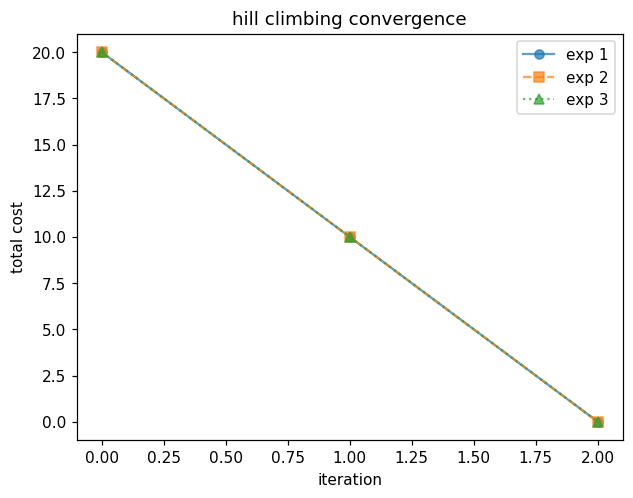

In [13]:
import matplotlib.pyplot as plt

styles = ['-o', '--s', ':^']
for (num, init), style in zip({1: [1,1,2,3,4,2], 2: [2,3,1,1,4,4], 3: [4,2,3,1,2,3]}.items(), styles):
    trace = cost_trace(init, conflicts, 4)
    plt.plot(range(len(trace)), trace, style, label=f'exp {num}', alpha=0.7)
plt.xlabel('iteration')
plt.ylabel('total cost')
plt.title('hill climbing convergence')
plt.legend()
plt.show()